In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

df_user = pd.read_csv("../dataset/user_twitter_data.csv")

# Liste des variables numériques 
features = [
    "followers_count", "friends_count", "statuses_count", "favourites_count",
    "listed_count", "retweet_count", "favorite_count", "reply_count", "quote_count",
    "hashtags_count", "urls_count", "mentions_count", "tweet_length",
    "is_retweet", "is_quote", "n_tweets", "followers_friends_ratio",
    "activity_ratio", "visibility_score"
]

#On isole les features à utiliser
X = df_user[features]

# K-means et PCA exigent des données normalisées (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#----------------------------------Echelle humaine --------------------------------------------------------------------------#
#Ici, on va utiliser 2 dimensions pour essayer de faire une modélisation compréhensible pour l'homme

# On applique la PCA pour condenser le tout sur 2 axes géométriques (PC1 et PC2)
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)

# On crée un DataFrame propre avec ces coordonnées pour ton K-means
df_clustering = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
df_clustering["user_id"] = df_user["user_id"]
df_clustering["screen_name"] = df_user["screen_name"]

df_clustering

,PC1,PC2,user_id,screen_name
0,6.952529,0.455064,418,dens
1,-0.084913,0.232943,730,crutis
2,0.627354,4.270116,761,RodBegbie
3,2.680392,0.843353,885,Ross
4,0.300918,-0.645254,922,Holger
...,...,...,...,...
1843434,-0.219370,-0.714520,1008392352644386816,vernett97925119
1843435,-0.219363,-0.714564,1008392445837692933,jacquly32294003
1843436,-0.274348,-1.774461,1008392594878066688,merrileenentwi5
1843437,-0.219377,-0.714476,1008392729930366976,annabel17990985


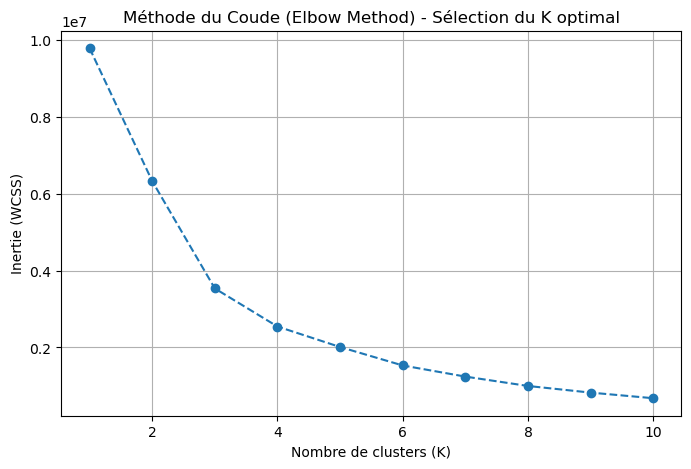

In [10]:
# La méthode du coude
# On crée une boucle qui va tester successivement l'algorithme en lui demandant de créer 1 cluster, puis 2, puis 3... jusqu'à 10 clusters.
# On va tester de 1 à 10 clusters pour voir où se trouve la "cassure"

wcss = []
max_k = 10

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_clustering[["PC1", "PC2"]])
    wcss.append(kmeans.inertia_)

# Graphique du Coude
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Méthode du Coude (Elbow Method) - Sélection du K optimal')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertie (WCSS)')
plt.grid(True)
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


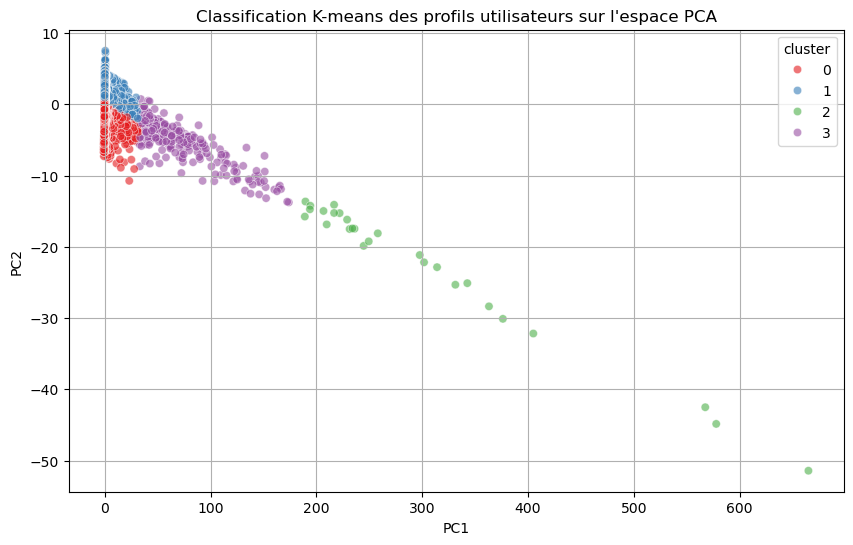

In [11]:
#En affichant cette courbe, on voit l'inertie chuter brutalement au début, puis stagner (la courbe s'aplatit). 
#L'endroit où la courbe forme un "coude" (une cassure)  représente le nombre idéal de groupes. Ici k = 4 
# Donc diviser notre population en 4 groupes est mathématiquement le choix le plus logique."

# A partir se ce qu'on a observé, on va changer la valeur de k
k_optimal = 4

kmeans_final = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
df_clustering['cluster'] = kmeans_final.fit_predict(df_clustering[["PC1", "PC2"]])

# Graphique final en couleur
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="PC1", y="PC2", 
    hue="cluster", 
    palette="Set1", 
    data=df_clustering, 
    alpha=0.6
)
plt.title("Classification K-means des profils utilisateurs sur l'espace PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [16]:
print("Variance totale expliquée :", sum(pca.explained_variance_ratio_)) # ~ 0.354
# Ceci montre les 2 axes sont trop faibles pour représenter la réalité
#L'écrasement visuel : Comme la PCA cherche à maximiser la variance donc elle étire les outliers et les utilisateurs normaux se retrouvent écrasés

Variance totale expliquée : 0.3536006204723433


C:\Users\kamgu\AppData\Local\Temp\ipykernel_26752\4080921379.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = np.log1p(X[col])


Nouvelle variance expliquée avec 5 axes : 100.00%
Variance des 2 premiers axes affichés : 100.00%


C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


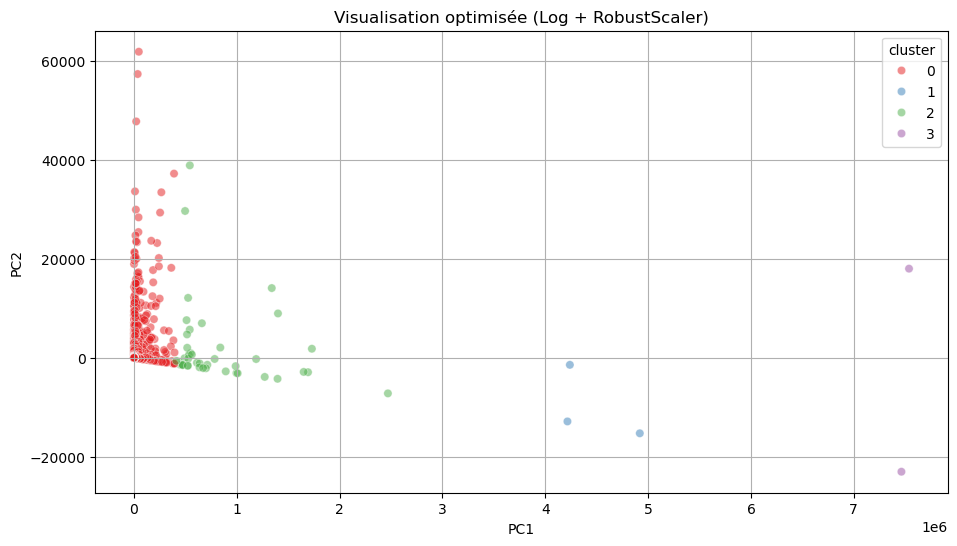

In [17]:
# Amélioration mathématique : On applique un log sur les compteurs pour resserrer les extrêmes
# Cela évite qu'un compte à 1 million de followers écrase un compte à 1000 followers

from sklearn.preprocessing import RobustScaler
for col in ["followers_count", "friends_count", "statuses_count", "favourites_count"]:
    X[col] = np.log1p(X[col])

# Normalisation robuste
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

#------------------------------------------------Clustering méthodique----------------------------------------#
#La PCA va chercher à résumer nos 19 dimensions en créant de nouvelles variables artificielles appelées Composantes Principales
# PCA méthodique (on prend 5 axes pour capter plus de variance)
pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Nouvelle variance expliquée avec 5 axes : {sum(pca.explained_variance_ratio_)*100:.2f}%")
print(f"Variance des 2 premiers axes affichés : {sum(pca.explained_variance_ratio_[:2])*100:.2f}%")

# Clustering K-means fait en 5D
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df_user['cluster'] = kmeans.fit_predict(X_pca)

# Extraction des coordonnées pour l'affichage 2D
df_user['PC1'] = X_pca[:, 0]
df_user['PC2'] = X_pca[:, 1]

# Affichage graphique (On zoome sur le cœur des données en limitant les axes si besoin)
plt.figure(figsize=(11, 6))
sns.scatterplot(
    x="PC1", y="PC2", 
    hue="cluster", 
    palette="Set1", 
    data=df_user, 
    alpha=0.5
)
plt.title("Visualisation optimisée (Log + RobustScaler)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [18]:
#Twitter possède des profils tellement extrêmes  qu'ils détruisent n'importe quelle représentation géométrique en 2D.
# On va essayer de faire parler les chiffres à la place. On sait déjà qu'on a 4 clusters

# On s'assure que la colonne cluster est bien dans le dataframe d'origine
df_user['cluster'] = kmeans_final.labels_

# Liste des caractéristiques clés à analyser (les plus parlantes pour le jury)
features_analyse = [
    "followers_count", "friends_count", "statuses_count", 
    "urls_count", "hashtags_count", "is_retweet", 
    "activity_ratio", "visibility_score", "n_tweets"
]

# Calcul de la moyenne par cluster
tableau_profils = df_user.groupby('cluster')[features_analyse].mean()

# On affiche aussi le nombre d'utilisateurs dans chaque groupe pour voir leur proportion
tableau_profils['nb_comptes_dans_cluster'] = df_user.groupby('cluster').size()

print("--- CARACTÉRISTIQUES MOYENNES DES CLUSTERS ---")
print(tableau_profils.round(2))  # Arrondi à 2 décimales pour la lisibilité

--- CARACTÉRISTIQUES MOYENNES DES CLUSTERS ---
         followers_count  friends_count  statuses_count  urls_count  \
cluster                                                               
0                2003.45         924.76        18070.86        0.07   
1                3352.18         758.62        16893.08        0.65   
2            21362759.41         997.22       125413.26        0.55   
3             4529365.60       30050.29       168780.55        0.56   

         hashtags_count  is_retweet  activity_ratio  visibility_score  \
cluster                                                                 
0                  1.81        0.93           46.49           2183.76   
1                  0.91        0.33           33.19           3622.27   
2                  1.38        0.22            0.01       21925272.53   
3                  1.78        0.31            0.23        4660517.98   

         n_tweets  nb_comptes_dans_cluster  
cluster                                   

In [ ]:
"""
Cluster 0 : Les "Amplificateurs Passifs" (La masse des utilisateurs)
- Qui ils sont : C'est le cœur du réseau (plus de 1,18 million de comptes).
- Leur comportement : Ils ont peu d'abonnés (~2000) et un nombre de tweets très faible dans le flux ($n\_tweets = 2.47$). 
  En revanche, leur taux de retweet est gigantesque (0.93, soit 93% de retweets).
- Interprétation : Ce sont des utilisateurs humains lambdas ou des comptes "spectateurs". 
  Pendant la Coupe du Monde, ils ne créent pas de contenu original : ils lisent et retweetent massivement les informations des autres.
  
Cluster 1 : Les "Créateurs / Partageurs Actifs" (Humains engagés)
- Qui ils sont : Le deuxième groupe le plus important (~661 000 comptes).
- Leur comportement : Ils ressemblent au cluster 0 en taille de compte (~3300 followers), mais leur comportement est inversé.
  Ils ne retweetent presque pas (0.33) et partagent beaucoup plus de liens externes (urls_count = 0.65 contre seulement 0.07 pour le cluster 0).
- Interprétation : Ce sont les utilisateurs actifs qui commentent les matchs en direct, écrivent leurs propres tweets et 
  partagent des articles ou des images (ce qui explique le taux d'URLs plus élevé).

Cluster 2 : Les "Méga-Célébrités / Médias Internationaux" (Profil Atypique 1)
- Qui ils sont : Un groupe minuscule de seulement 27 comptes.
- Leur comportement : C’est à cause d’eux que le graphique était écrasé. Ils ont en moyenne 21,3 millions de followers chacun, 
  un visibility_score stratosphérique de 21 millions, et un score d'activité proche de 0 (car ils n'ont pas besoin de spammer pour être vus). 
  Ils écrivent beaucoup plus de tweets originaux ($n\_tweets = 9.78$).
- Interprétation : Ce sont les comptes officiels de la FIFA, des joueurs stars (Mbappé, Messi, Ronaldo) ou de très grands médias (ESPN, BeIN Sports).

Cluster 3 : Les "Super-Diffuseurs / Professionnels de l'Information" (Profil Atypique 2)
- Qui ils sont : Une petite élite de 326 comptes.
- Leur comportement : Ils combinent une très forte audience (4,5 millions de followers), un nombre immense d'abonnements (friends_count = 30 050) 
  et une activité historique colossale (statuses_count = 168 780). Dans le flux de données, ce sont eux qui bombardent le plus : 
  ils ont écrit en moyenne 15,44 tweets chacun durant l'événement, avec beaucoup d'URLs (0.56) et de hashtags (1.78).
- Interprétation : Ce sont les journalistes sportifs, les influenceurs Twitter très installés, ou les comptes officiels de clubs/fédérations 
  qui font vivre le "live-texte" du mondial à la chaîne.

Les 27 comptes du Cluster 2 et les 326 comptes du Cluster 3 sont tellement gigantesques par rapport aux utilisateurs normaux 
qu'ils ont relégué 99,9% du dataset tout au début de l'axe (proche de 0).
"""